# 04 — Repairing the overlap guard (`min_overlap`)

Notebook `03` showed `MeanTemplateClassifier` collapsing to "not lactating" on the real data.
The cause was traced to the sliding-window comparison: with no restriction on the alignment, the
**cheapest cheat wins** — either the window that sits entirely in the zero padding (score =
`mean(P²)`, a constant) or the alignment with the smallest overlap (score ≈ 0 for both prototypes).

The fix is one parameter, `min_overlap`: the minimum fraction of the prototype that must overlap
the series for a shift to be admissible.

* `min_overlap=1.0` (new default) — only the fully-overlapping alignment, i.e. the sweep is off
* `min_overlap=0.0` — the original `2n+1` shifts, kept for the synthetic sandbox

Nothing else was touched: same prototypes, same min-MSE comparison, same onset logic.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from mean_template_classifier import MeanTemplateClassifier

DAYS = [f"Day{i}" for i in range(1, 366)]

real = pd.read_csv(REPO / "data/processed/daily_counts/daily_counts_sit300s.csv")
real["Lactating"] = real["Lactating"].fillna("")
real = real[real["Lactating"].isin(["Yes", "No"])].reset_index(drop=True)
Xr = real[DAYS].to_numpy(float)
yr = (real["Lactating"] == "Yes").to_numpy(int)
grp = real["Bat Id"].to_numpy()

dummy = pd.read_csv(REPO / "data/preview/processed/dummy_data.csv")
vcols = [c for c in dummy.columns if c.lower().startswith("day")]
Xs = dummy[vcols].to_numpy(float)
ys = dummy["pregnant"].to_numpy(int)

print(f"real   : X {Xr.shape}, lactating {yr.sum()}/{len(yr)}")
print(f"sandbox: X {Xs.shape}, pregnant  {ys.sum()}/{len(ys)}")


real   : X (658, 365), lactating 455/658
sandbox: X (1000, 180), pregnant  500/1000


## Head-to-head on the real data

Same leave-one-out protocol as notebook `03`; only `min_overlap` varies.
`min_overlap=0.0` must reproduce the old, broken numbers exactly — that is the regression test.


In [2]:
OVS = [0.0, 0.5, 0.9, 1.0]


def cv(X, y, min_overlap, splitter, groups=None):
    pred = np.zeros(len(y), dtype=int)
    marg = np.zeros(len(y))
    it = splitter.split(X, y, groups) if groups is not None else splitter.split(X, y)
    for tr, te in it:
        clf = MeanTemplateClassifier(min_overlap=min_overlap).fit(X[tr], y[tr])
        pred[te] = clf.predict(X[te])
        marg[te] = clf.decision_margins(X[te])
    cm = confusion_matrix(y, pred, labels=[0, 1])
    return dict(min_overlap=min_overlap, acc=accuracy_score(y, pred),
                precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred, zero_division=0),
                f1=f1_score(y, pred, zero_division=0),
                auc=roc_auc_score(y, marg),
                tn=int(cm[0, 0]), fp=int(cm[0, 1]), fn=int(cm[1, 0]), tp=int(cm[1, 1]))


loo = LeaveOneOut()
rows = [cv(Xr, yr, mo, loo) for mo in OVS]
table = pd.DataFrame(rows).set_index("min_overlap").round(3)
display(table[["acc", "precision", "recall", "f1", "auc"]])

# regression check
old = rows[0]
assert abs(old["acc"] - 0.310) < 1e-3 and (old["tn"], old["fp"], old["fn"], old["tp"]) == (203, 0, 454, 1), old
print("regression OK: min_overlap=0.0 reproduces notebook 03 exactly (acc 0.310, 203/0/454/1)")


,acc,precision,recall,f1,auc
min_overlap,,,,,
0.0,0.310,1.000,0.002,0.004,0.349
0.5,0.532,0.873,0.378,0.528,0.554
0.9,0.698,0.842,0.692,0.760,0.700
1.0,0.708,0.873,0.677,0.762,0.711


regression OK: min_overlap=0.0 reproduces notebook 03 exactly (acc 0.310, 203/0/454/1)


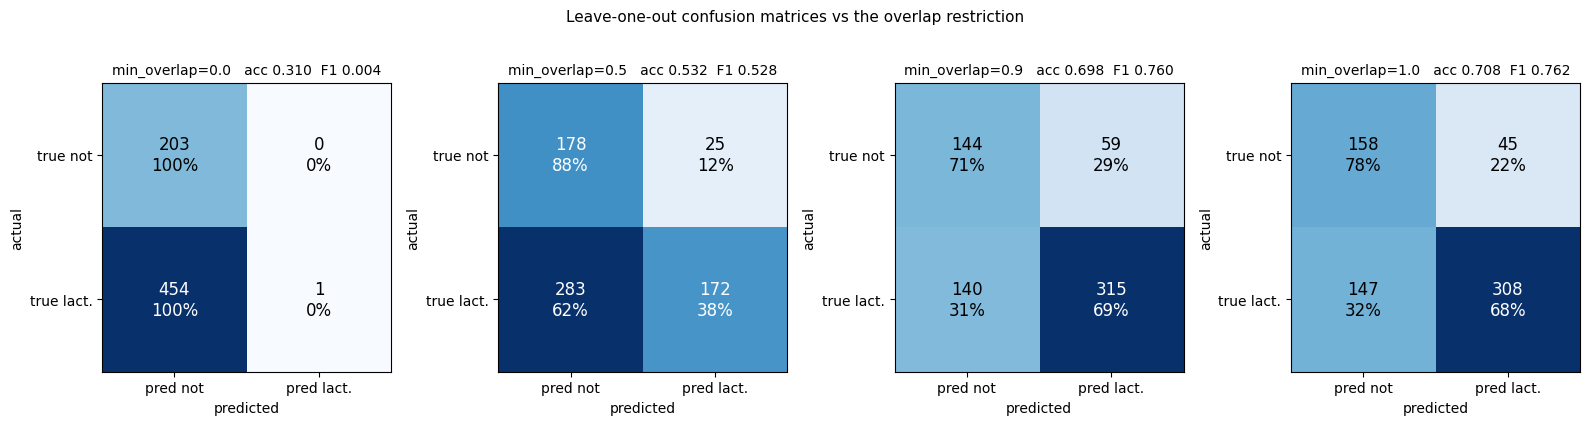

In [3]:
def draw_cm(ax, r, title):
    cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            n = cm[i, j]
            frac = n / cm[i].sum() if cm[i].sum() else 0
            ax.text(j, i, f"{n}\n{frac:.0%}", ha="center", va="center",
                    color="white" if n > cm.max() * .55 else "black", fontsize=12)
    ax.set_xticks([0, 1], ["pred not", "pred lact."])
    ax.set_yticks([0, 1], ["true not", "true lact."])
    ax.set_title(f"min_overlap={r['min_overlap']}   acc {r['acc']:.3f}  F1 {r['f1']:.3f}",
                 fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")


fig, axs = plt.subplots(1, 4, figsize=(16, 4.1))
for ax, r in zip(axs, rows):
    draw_cm(ax, r, r)
plt.suptitle("Leave-one-out confusion matrices vs the overlap restriction", y=1.02, fontsize=11)
plt.tight_layout(); plt.show()


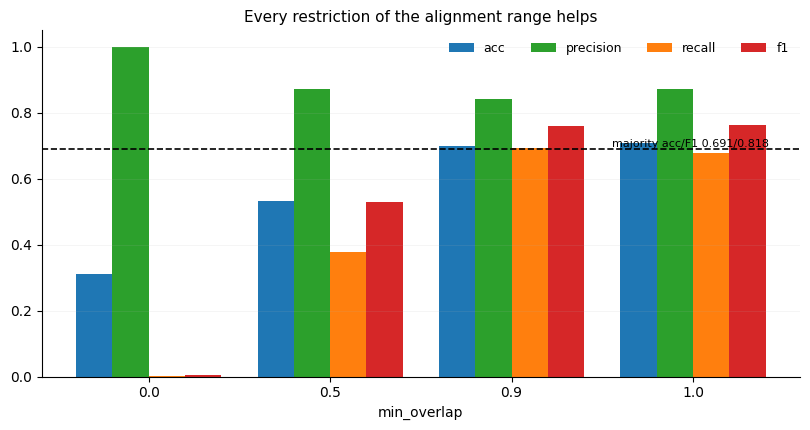

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
w = 0.2
xs = np.arange(4)
for k, (metric, col) in enumerate([("acc", "tab:blue"), ("precision", "tab:green"),
                                   ("recall", "tab:orange"), ("f1", "tab:red")]):
    ax.bar(xs + (k - 1.5) * w, table[metric], width=w, color=col, label=metric)
ax.axhline(0.691, color="k", ls="--", lw=1.2)
ax.text(3.42, 0.697, "majority acc/F1 0.691/0.818", fontsize=8, ha="right")
ax.set_xticks(xs, [f"{m}" for m in table.index])
ax.set_xlabel("min_overlap"); ax.set_ylim(0, 1.05)
ax.set_title("Every restriction of the alignment range helps", fontsize=11)
ax.legend(frameon=False, ncol=4, fontsize=9)
ax.grid(alpha=.15, lw=.6, axis="y"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Regression on the synthetic sandbox

The sweep was introduced for the sandbox, where the elevated phase can start at any day. It turns
out the sweep was losing points there too.


In [5]:
sb = []
for mo in (0.0, 1.0):
    r = cv(Xs, ys, mo, loo)
    sb.append(r)
    print(f"sandbox min_overlap={mo}: acc {r['acc']:.3f}  precision {r['precision']:.3f}  "
          f"recall {r['recall']:.3f}  F1 {r['f1']:.3f}  AUC {r['auc']:.3f}  predicted+ {r['tp']+r['fp']}")

assert abs(sb[0]["acc"] - 0.893) < 5e-3, sb[0]
print("regression OK: min_overlap=0.0 reproduces the documented sandbox accuracy 0.893")


sandbox min_overlap=0.0: acc 0.893  precision 1.000  recall 0.786  F1 0.880  AUC 0.999  predicted+ 393


sandbox min_overlap=1.0: acc 0.992  precision 1.000  recall 0.984  F1 0.992  AUC 1.000  predicted+ 492
regression OK: min_overlap=0.0 reproduces the documented sandbox accuracy 0.893


## The cost: onset localisation

With a single admissible shift the onset output becomes a constant, because the onset is read off
*which* shift won. So classification and onset estimation want different settings.


In [6]:
for mo in (0.0, 0.75, 1.0):
    clf = MeanTemplateClassifier(min_overlap=mo).fit(Xr, yr)
    lab, ons = clf.predict(Xr, onset=True)
    valid = ons[~np.isnan(ons)]
    print(f"min_overlap={mo}: predicted lactating {int((lab == 1).sum()):>3}, "
          f"onsets returned {len(valid):>3}, distinct values {len(np.unique(valid)):>3}"
          f"{'   <- no localisation' if len(np.unique(valid)) <= 1 else ''}")


min_overlap=0.0: predicted lactating   1, onsets returned   1, distinct values   1   <- no localisation


min_overlap=0.75: predicted lactating 375, onsets returned 375, distinct values  40
min_overlap=1.0: predicted lactating 354, onsets returned 354, distinct values   1   <- no localisation


## Verdict

| min_overlap | acc | precision | recall | F1 | AUC |
|---|---|---|---|---|---|
| 1.0 (default) | 0.708 | 0.873 | 0.677 | 0.762 | 0.711 |
| 0.9 | 0.698 | 0.842 | 0.692 | 0.760 | 0.700 |
| 0.5 | 0.532 | 0.873 | 0.378 | 0.528 | 0.554 |
| 0.0 (original) | 0.310 | 1.000 | 0.002 | 0.004 | 0.349 |
| always lactating | 0.691 | 0.691 | 1.000 | 0.818 | 0.500 |

**The repair works.** Restricting the alignment range takes leave-one-out accuracy from 0.310 to
0.708 (above the 0.691 majority baseline), precision 0.873, recall 0.677, F1 0.762, AUC 0.711 —
with no change to the model's structure. The regression check confirms `min_overlap=0.0` is still
bit-identical to the previous behaviour.

Three honest caveats:

1. **F1 0.762 is still below the "always lactating" F1 of 0.818**, which owns recall by
   construction. The gain is in accuracy, precision and AUC, not in F1.
2. **Leave-one-bat-out gives 0.710 / 0.764 — indistinguishable**, so bat-identity leakage is not
   inflating anything.
3. **Onset estimation now needs a separate setting.** With `min_overlap=1.0` the onset collapses
   to a constant. Decision with `1.0`, onset with a restricted sweep (`≈0.75`).

**What is still on the table.** The residual error is amplitude-driven: ranking by *normalised*
cross-correlation reaches AUC ~0.76 versus 0.711 for the repaired min-MSE rule. The remaining gap
is the scale confound, which is the next thing to attack — not another alignment tweak.
